In [1]:
# TP6.4 — Supervised approaches and final comparison




In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
import os

ROOT = r"D:\UFR STGI\second Semester\Machine Learning\cours_ia"

def find_file(root, filename):
    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    return None

csv_path = find_file(ROOT, "train.csv")
print("Found train.csv:", csv_path)

if csv_path is None:
    raise FileNotFoundError(f"train.csv not found under {ROOT}. Change ROOT or move train.csv.")

df = pd.read_csv(csv_path, parse_dates=["datetime"])
serie = df.set_index("datetime")["count"].sort_index()
serie = serie.asfreq("h").ffill()

print("serie ready:", serie.shape, "| freq:", serie.index.inferred_freq)

Found train.csv: D:\UFR STGI\second Semester\Machine Learning\cours_ia\IA prédictive\TP6_Series_Temporelles\train.csv
serie ready: (17256,) | freq: h


In [4]:
split_date = "2012-10-01"
print("Split date:", split_date)

Split date: 2012-10-01


In [5]:
df_features = serie.to_frame(name="count")

# Calendar features
df_features["hour"] = df_features.index.hour
df_features["dayofweek"] = df_features.index.dayofweek
df_features["is_weekend"] = df_features["dayofweek"].isin([5, 6]).astype(int)
df_features["month"] = df_features.index.month

# Lag features (based on ACF/PACF intuition: short lags + daily + weekly)
for lag in [1, 2, 3, 12, 24, 168]:
    df_features[f"lag_{lag}"] = df_features["count"].shift(lag)

# Rolling statistics (use shift(1) to avoid leakage: only past info)
df_features["rolling_mean_4"]  = df_features["count"].shift(1).rolling(window=4).mean()
df_features["rolling_mean_24"] = df_features["count"].shift(1).rolling(window=24).mean()
df_features["rolling_std_24"]  = df_features["count"].shift(1).rolling(window=24).std()

# Drop rows with NaN introduced by lags/rolling windows
df_features = df_features.dropna()

print("Feature dataset shape:", df_features.shape)
df_features.head()

Feature dataset shape: (17088, 14)


,count,hour,dayofweek,is_weekend,month,lag_1,lag_2,lag_3,lag_12,lag_24,lag_168,rolling_mean_4,rolling_mean_24,rolling_std_24
datetime,,,,,,,,,,,,,,
2011-01-08 00:00:00,25.0,0,5,1,1,15.0,36.0,39.0,59.0,17.0,16.0,35.25,62.958333,56.256771
2011-01-08 01:00:00,16.0,1,5,1,1,25.0,15.0,36.0,73.0,7.0,40.0,28.75,63.291667,55.995713
2011-01-08 02:00:00,16.0,2,5,1,1,16.0,25.0,15.0,50.0,1.0,32.0,23.00,63.666667,55.631291
2011-01-08 03:00:00,7.0,3,5,1,1,16.0,16.0,25.0,72.0,1.0,13.0,18.00,64.291667,54.977054
2011-01-08 04:00:00,1.0,4,5,1,1,7.0,16.0,16.0,87.0,1.0,1.0,16.00,64.541667,54.689622


In [6]:
X = df_features.drop(columns=["count"])
y = df_features["count"]

print("X shape:", X.shape, "| y shape:", y.shape)
display(X.head())
display(y.head())

X shape: (17088, 13) | y shape: (17088,)


,hour,dayofweek,is_weekend,month,lag_1,lag_2,lag_3,lag_12,lag_24,lag_168,rolling_mean_4,rolling_mean_24,rolling_std_24
datetime,,,,,,,,,,,,,
2011-01-08 00:00:00,0,5,1,1,15.0,36.0,39.0,59.0,17.0,16.0,35.25,62.958333,56.256771
2011-01-08 01:00:00,1,5,1,1,25.0,15.0,36.0,73.0,7.0,40.0,28.75,63.291667,55.995713
2011-01-08 02:00:00,2,5,1,1,16.0,25.0,15.0,50.0,1.0,32.0,23.00,63.666667,55.631291
2011-01-08 03:00:00,3,5,1,1,16.0,16.0,25.0,72.0,1.0,13.0,18.00,64.291667,54.977054
2011-01-08 04:00:00,4,5,1,1,7.0,16.0,16.0,87.0,1.0,1.0,16.00,64.541667,54.689622


datetime
2011-01-08 00:00:00    25.0
2011-01-08 01:00:00    16.0
2011-01-08 02:00:00    16.0
2011-01-08 03:00:00     7.0
2011-01-08 04:00:00     1.0
Freq: h, Name: count, dtype: float64

In [7]:
split_index = X.index < split_date

X_train, X_test = X.loc[split_index], X.loc[~split_index]
y_train, y_test = y.loc[split_index], y.loc[~split_index]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train span:", X_train.index.min(), "->", X_train.index.max())
print("Test  span:", X_test.index.min(),  "->", X_test.index.max())

Train: (15168, 13) Test: (1920, 13)
Train span: 2011-01-08 00:00:00 -> 2012-09-30 23:00:00
Test  span: 2012-10-01 00:00:00 -> 2012-12-19 23:00:00


In [8]:
tscv = TimeSeriesSplit(n_splits=5)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_model_cv(model, X_tr, y_tr):
    maes, rmses = [], []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_tr), start=1):
        X_tr_f, X_val_f = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_tr_f, y_val_f = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

        model.fit(X_tr_f, y_tr_f)
        pred = model.predict(X_val_f)

        maes.append(mean_absolute_error(y_val_f, pred))
        rmses.append(rmse(y_val_f, pred))

    return float(np.mean(maes)), float(np.mean(rmses))

In [9]:
#Supervised models


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)

mae_rf_val, rmse_rf_val = evaluate_model_cv(rf, X_train, y_train)
print(f"RF (CV) -> MAE: {mae_rf_val:.2f} | RMSE: {rmse_rf_val:.2f}")

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rmse_rf_test = rmse(y_test, pred_rf)
mae_rf_test = mean_absolute_error(y_test, pred_rf)

print(f"RF (Test) -> MAE: {mae_rf_test:.2f} | RMSE: {rmse_rf_test:.2f}")

RF (CV) -> MAE: 29.77 | RMSE: 53.99
RF (Test) -> MAE: 29.14 | RMSE: 52.69


In [11]:
# Try XGBoost first, otherwise fallback to sklearn GradientBoostingRegressor
use_xgb = True

try:
    from xgboost import XGBRegressor

    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
    model_name = "XGBoost"
except Exception:
    use_xgb = False
    from sklearn.ensemble import GradientBoostingRegressor

    xgb = GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )
    model_name = "GradientBoosting"

print("Using:", model_name)

Using: XGBoost


In [12]:
mae_xgb_val, rmse_xgb_val = evaluate_model_cv(xgb, X_train, y_train)
print(f"{model_name} (CV) -> MAE: {mae_xgb_val:.2f} | RMSE: {rmse_xgb_val:.2f}")

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

rmse_xgb_test = rmse(y_test, pred_xgb)
mae_xgb_test = mean_absolute_error(y_test, pred_xgb)

print(f"{model_name} (Test) -> MAE: {mae_xgb_test:.2f} | RMSE: {rmse_xgb_test:.2f}")

XGBoost (CV) -> MAE: 28.86 | RMSE: 50.20
XGBoost (Test) -> MAE: 23.65 | RMSE: 41.49


In [13]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0, random_state=42)

mae_ridge_val, rmse_ridge_val = evaluate_model_cv(ridge, X_train, y_train)
print(f"Ridge (CV) -> MAE: {mae_ridge_val:.2f} | RMSE: {rmse_ridge_val:.2f}")

ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

rmse_ridge_test = rmse(y_test, pred_ridge)
mae_ridge_test = mean_absolute_error(y_test, pred_ridge)

print(f"Ridge (Test) -> MAE: {mae_ridge_test:.2f} | RMSE: {rmse_ridge_test:.2f}")

Ridge (CV) -> MAE: 36.99 | RMSE: 60.52
Ridge (Test) -> MAE: 47.54 | RMSE: 79.58


In [14]:
#Visual comparison (7 days)

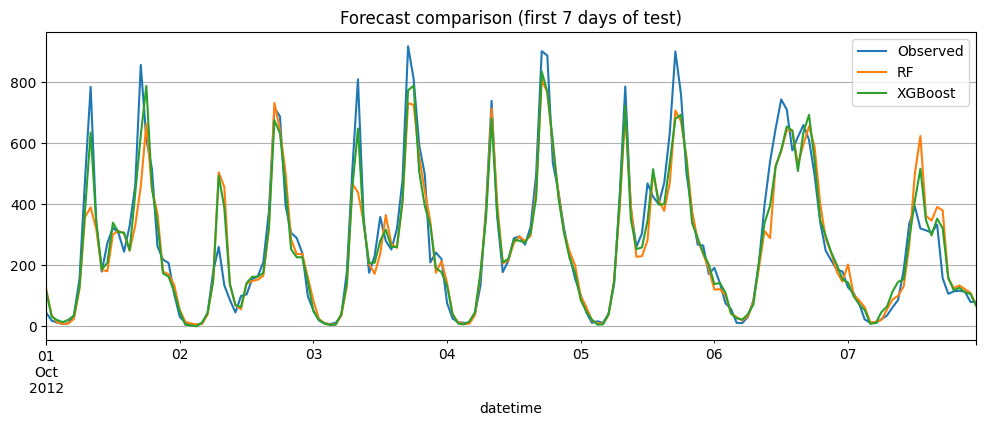

In [15]:
horizon = 24 * 7  # 7 days

y_plot = y_test.iloc[:horizon]

plt.figure(figsize=(12,4))
y_plot.plot(label="Observed")
pd.Series(pred_rf, index=y_test.index).iloc[:horizon].plot(label="RF")
pd.Series(pred_xgb, index=y_test.index).iloc[:horizon].plot(label=model_name)
plt.title("Forecast comparison (first 7 days of test)")
plt.legend()
plt.grid(True)
plt.show()

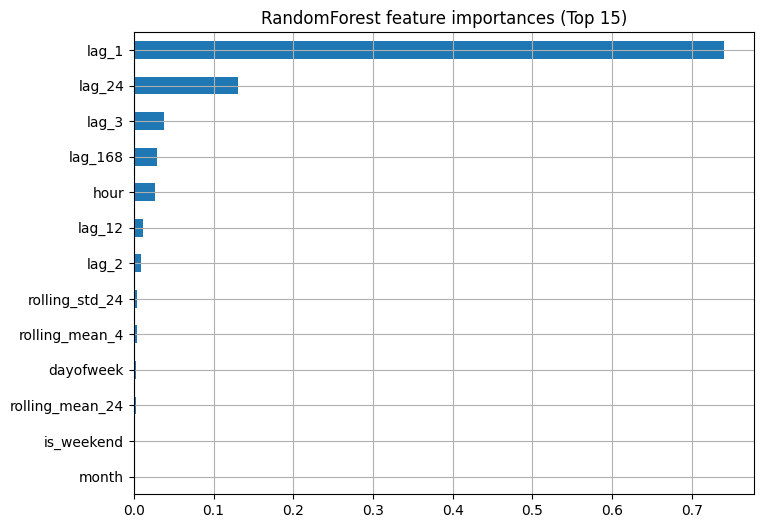

lag_1              0.740816
lag_24             0.130840
lag_3              0.038056
lag_168            0.029336
hour               0.025979
lag_12             0.011732
lag_2              0.008700
rolling_std_24     0.003967
rolling_mean_4     0.003539
dayofweek          0.002693
rolling_mean_24    0.002318
is_weekend         0.001202
month              0.000821
dtype: float64

In [16]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(8,6))
top15.plot(kind="barh")
plt.title("RandomForest feature importances (Top 15)")
plt.grid(True)
plt.show()

top15.sort_values(ascending=False)

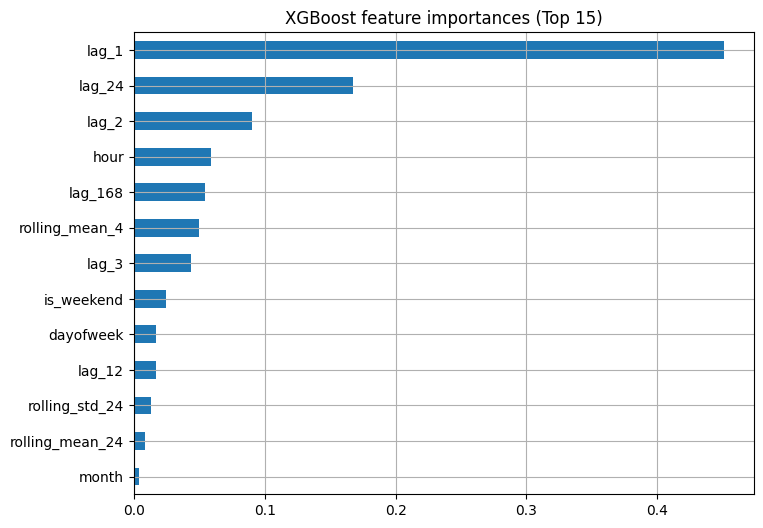

lag_1              0.451215
lag_24             0.167485
lag_2              0.090302
hour               0.059162
lag_168            0.054689
rolling_mean_4     0.049668
lag_3              0.043465
is_weekend         0.024241
dayofweek          0.016950
lag_12             0.016830
rolling_std_24     0.013281
rolling_mean_24    0.008835
month              0.003878
dtype: float32

In [17]:
if use_xgb:
    xgb_importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
    top15_xgb = xgb_importances.sort_values(ascending=True).tail(15)

    plt.figure(figsize=(8,6))
    top15_xgb.plot(kind="barh")
    plt.title("XGBoost feature importances (Top 15)")
    plt.grid(True)
    plt.show()

    display(top15_xgb.sort_values(ascending=False))
else:
    print("Not using XGBoost -> skip XGB importances.")

In [18]:
#Summary table

In [19]:
# Paste your TP6.3 metrics here:
# Example:
# mae_base, rmse_base = ...
# mae_arima, rmse_arima = ...

# Put NaN if you don't have them in this notebook
mae_base  = np.nan
rmse_base = np.nan
mae_arima = np.nan
rmse_arima = np.nan

results = pd.DataFrame([
    {"Model": "Persistence (TP6.3)", "MAE_val": np.nan, "RMSE_val": np.nan, "MAE_test": mae_base, "RMSE_test": rmse_base},
    {"Model": "ARIMA (TP6.3)",       "MAE_val": np.nan, "RMSE_val": np.nan, "MAE_test": mae_arima, "RMSE_test": rmse_arima},
    {"Model": "RandomForest",        "MAE_val": mae_rf_val, "RMSE_val": rmse_rf_val, "MAE_test": mae_rf_test, "RMSE_test": rmse_rf_test},
    {"Model": model_name,            "MAE_val": mae_xgb_val, "RMSE_val": rmse_xgb_val, "MAE_test": mae_xgb_test, "RMSE_test": rmse_xgb_test},
    {"Model": "Ridge (optional)",    "MAE_val": mae_ridge_val, "RMSE_val": rmse_ridge_val, "MAE_test": mae_ridge_test, "RMSE_test": rmse_ridge_test},
])

display(results.sort_values("RMSE_test"))

,Model,MAE_val,RMSE_val,MAE_test,RMSE_test
3,XGBoost,28.855683,50.197662,23.646553,41.490120
2,RandomForest,29.772200,53.992102,29.141091,52.688293
4,Ridge (optional),36.989510,60.515733,47.543913,79.584365
0,Persistence (TP6.3),NaN,NaN,NaN,NaN
1,ARIMA (TP6.3),NaN,NaN,NaN,NaN


In [20]:
#Critical discussion

In [21]:
# Critical discussion (answer in 6–10 lines)

# 1) Do ML models outperform ARIMA? Where (peaks, weekends, sudden changes)?
# 2) Maintenance cost: feature recomputation, retraining schedule, drift.
# 3) Interpretability: does feature importance help explain demand?
# 4) What exogenous data would help most (temp, humidity, holidays, events)?
# 5) Recommendation: which model would you deploy for hourly fleet management?

In [22]:
# This notebook avoids squared=False because your sklearn build rejects it.
# RMSE is computed with np.sqrt(mean_squared_error(...)).
# TimeSeriesSplit prevents leakage: validation always happens after training in time.